# 분류 모델 (후판 공정)

- 압연공정에서 scale 불량

[분석 기법]
1. 그래프를 활용한 탐색적 분석
2. 로지스틱 회귀분석
3. 의사결정 트리
4. 앙상블 모델(Random Forest, Gradient Boosting)
5. KNN

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (10.1 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121752 files and direc

In [ ]:


# #맥 전용 폰트
# !apt-get update -qq
# !apt-get install fonts-nanum* -qq

# import matplotlib.pyplot as plt
# import matplotlib.font_manager as fm
# fm._rebuild()
# plt.rc('font', family='NanumGothic')

In [ ]:
#드라이브마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 데이터 구성:Series, DataFrame
import pandas as pd
# 행렬 연산
import numpy as np
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

import seaborn as sns
# scaling
from sklearn.preprocessing import StandardScaler
# 데이터 분할:train, test
from sklearn.model_selection import train_test_split
# 로지스틱 회귀
from statsmodels.api import Logit
import statsmodels.api as sm
# 분류모델 평가 함수
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn import metrics
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import export_graphviz
from sklearn.neighbors import KNeighborsClassifier
import graphviz

import matplotlib

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')

#데이터 불러오기 및 전처리

In [ ]:
#코랩

df_raw = pd.read_csv("/content/drive/MyDrive/최강<포빅아A4>/후판공정/SCALE불량.csv", encoding = 'euc-kr')
df_raw.head()


,plate_no,rolling_date,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,...,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,fur_ex_temp,rolling_method,rolling_temp,descaling_count,work_group
0,PLT_1001,03JAN2023:07:07:53,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,...,1144,116,1133,59,259,1133,TMCP(온도제어),934,8,1조
1,PLT_1002,03JAN2023:07:21:22,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,...,1144,122,1135,53,238,1135,TMCP(온도제어),937,8,1조
2,PLT_1003,03JAN2023:07:31:15,양품,NV-E36-TM,영국,T,33,3600,19200,적용,...,1129,116,1121,55,258,1121,TMCP(온도제어),889,8,1조
3,PLT_1004,03JAN2023:07:41:01,양품,NV-E36-TM,영국,T,33,3600,19200,적용,...,1152,125,1127,68,266,1127,TMCP(온도제어),885,8,1조
4,PLT_1005,03JAN2023:07:52:40,양품,BV-EH36-TM,프랑스,T,38,3100,13300,적용,...,1140,134,1128,48,246,1128,TMCP(온도제어),873,8,1조


In [ ]:
# #주피터
# df_raw = pd.read_csv("C:/Users/joohy/BigData/data/SCALE불량.csv", encoding = 'euc-kr')
# df_raw.head()

후판공정은 4조 2교대  
rolling_date 열을 이용해 2교대로 나눌 것.  
2교대는 7to19, 19to7 로 나뉨

In [ ]:
df_raw['work_group'].value_counts()

2조    292
1조    280
3조    218
4조    210
Name: work_group, dtype: int64

rolling_date 전처리

In [ ]:
# ":" 이후의 문자열을 추출하고 첫번째값 저장하여 time으로 저장. 2교대라 시간만 저장
df_raw['time'] = df_raw['rolling_date'].str.split(":", expand=True)[1]

df_raw.head()


,plate_no,rolling_date,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,...,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,fur_ex_temp,rolling_method,rolling_temp,descaling_count,work_group,time
0,PLT_1001,03JAN2023:07:07:53,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,...,116,1133,59,259,1133,TMCP(온도제어),934,8,1조,07
1,PLT_1002,03JAN2023:07:21:22,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,...,122,1135,53,238,1135,TMCP(온도제어),937,8,1조,07
2,PLT_1003,03JAN2023:07:31:15,양품,NV-E36-TM,영국,T,33,3600,19200,적용,...,116,1121,55,258,1121,TMCP(온도제어),889,8,1조,07
3,PLT_1004,03JAN2023:07:41:01,양품,NV-E36-TM,영국,T,33,3600,19200,적용,...,125,1127,68,266,1127,TMCP(온도제어),885,8,1조,07
4,PLT_1005,03JAN2023:07:52:40,양품,BV-EH36-TM,프랑스,T,38,3100,13300,적용,...,134,1128,48,246,1128,TMCP(온도제어),873,8,1조,07


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   plate_no         1000 non-null   object
 1   rolling_date     1000 non-null   object
 2   scale            1000 non-null   object
 3   spec_long        1000 non-null   object
 4   spec_country     1000 non-null   object
 5   steel_kind       1000 non-null   object
 6   pt_thick         1000 non-null   int64 
 7   pt_width         1000 non-null   int64 
 8   pt_length        1000 non-null   int64 
 9   hsb              1000 non-null   object
 10  fur_no           1000 non-null   object
 11  fur_input_row    1000 non-null   object
 12  fur_heat_temp    1000 non-null   int64 
 13  fur_heat_time    1000 non-null   int64 
 14  fur_soak_temp    1000 non-null   int64 
 15  fur_soak_time    1000 non-null   int64 
 16  fur_total_time   1000 non-null   int64 
 17  fur_ex_temp      1000 non-null   i

In [ ]:
# time열 정수형으로 변환
df_raw['time']= df_raw['time'].astype('int64')

In [ ]:
#time이 7시부터 19시 전까지는 주간, 19시보다 크고, 7시 미만은 야간로 저장

# 'rotation' 열 생성하는 함수
def determine_rotation(time):
    if 7 <= time < 19:
        return '주간'
    else:
        return '야간'

# 'rotation' 열 생성
df_raw['rotation'] = df_raw['time'].apply(determine_rotation)

df_raw

,plate_no,rolling_date,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,...,fur_soak_temp,fur_soak_time,fur_total_time,fur_ex_temp,rolling_method,rolling_temp,descaling_count,work_group,time,rotation
0,PLT_1001,03JAN2023:07:07:53,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,...,1133,59,259,1133,TMCP(온도제어),934,8,1조,7,주간
1,PLT_1002,03JAN2023:07:21:22,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,...,1135,53,238,1135,TMCP(온도제어),937,8,1조,7,주간
2,PLT_1003,03JAN2023:07:31:15,양품,NV-E36-TM,영국,T,33,3600,19200,적용,...,1121,55,258,1121,TMCP(온도제어),889,8,1조,7,주간
3,PLT_1004,03JAN2023:07:41:01,양품,NV-E36-TM,영국,T,33,3600,19200,적용,...,1127,68,266,1127,TMCP(온도제어),885,8,1조,7,주간
4,PLT_1005,03JAN2023:07:52:40,양품,BV-EH36-TM,프랑스,T,38,3100,13300,적용,...,1128,48,246,1128,TMCP(온도제어),873,8,1조,7,주간
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,PLT_1996,10JAN2023:05:32:25,양품,BV-A,프랑스,C,19,3400,41500,적용,...,1151,86,203,1151,CR(제어압연),948,10,4조,5,야간
996,PLT_1997,10JAN2023:05:39:19,양품,LR-A,영국,C,19,3400,41500,적용,...,1151,86,209,1151,CR(제어압연),948,10,4조,5,야간
997,PLT_1998,10JAN2023:05:52:41,양품,AB/AH32,미국,C,17,3400,43700,적용,...,1163,77,227,1163,CR(제어압연),948,10,4조,5,야간
998,PLT_1999,10JAN2023:06:01:50,양품,NV-A32,영국,C,17,3400,43700,적용,...,1163,77,204,1163,CR(제어압연),948,10,4조,6,야간


In [ ]:
df_raw['rotation'].value_counts()

야간    502
주간    498
Name: rotation, dtype: int64

In [ ]:
#rolling_date , time 열 삭제

df_raw = df_raw.drop(['rolling_date','time'], axis =1 )

In [ ]:
#같은 데이터 가진 열 삭제
df_raw = df_raw.drop('fur_ex_temp',axis = 1)
df_raw

,plate_no,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,fur_no,...,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group,rotation
0,PLT_1001,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,1호기,...,1144,116,1133,59,259,TMCP(온도제어),934,8,1조,주간
1,PLT_1002,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,1호기,...,1144,122,1135,53,238,TMCP(온도제어),937,8,1조,주간
2,PLT_1003,양품,NV-E36-TM,영국,T,33,3600,19200,적용,2호기,...,1129,116,1121,55,258,TMCP(온도제어),889,8,1조,주간
3,PLT_1004,양품,NV-E36-TM,영국,T,33,3600,19200,적용,2호기,...,1152,125,1127,68,266,TMCP(온도제어),885,8,1조,주간
4,PLT_1005,양품,BV-EH36-TM,프랑스,T,38,3100,13300,적용,3호기,...,1140,134,1128,48,246,TMCP(온도제어),873,8,1조,주간
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,PLT_1996,양품,BV-A,프랑스,C,19,3400,41500,적용,1호기,...,1142,55,1151,86,203,CR(제어압연),948,10,4조,야간
996,PLT_1997,양품,LR-A,영국,C,19,3400,41500,적용,1호기,...,1142,55,1151,86,209,CR(제어압연),948,10,4조,야간
997,PLT_1998,양품,AB/AH32,미국,C,17,3400,43700,적용,2호기,...,1169,65,1163,77,227,CR(제어압연),948,10,4조,야간
998,PLT_1999,양품,NV-A32,영국,C,17,3400,43700,적용,2호기,...,1169,65,1163,77,204,CR(제어압연),948,10,4조,야간


In [ ]:
# Plate no 삭제

df_raw = df_raw.drop('plate_no', axis = 1)
df_raw.head()

,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,fur_no,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group,rotation
0,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,1호기,1열,1144,116,1133,59,259,TMCP(온도제어),934,8,1조,주간
1,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,1호기,2열,1144,122,1135,53,238,TMCP(온도제어),937,8,1조,주간
2,양품,NV-E36-TM,영국,T,33,3600,19200,적용,2호기,1열,1129,116,1121,55,258,TMCP(온도제어),889,8,1조,주간
3,양품,NV-E36-TM,영국,T,33,3600,19200,적용,2호기,2열,1152,125,1127,68,266,TMCP(온도제어),885,8,1조,주간
4,양품,BV-EH36-TM,프랑스,T,38,3100,13300,적용,3호기,1열,1140,134,1128,48,246,TMCP(온도제어),873,8,1조,주간


In [ ]:
df_raw['spec_long'].unique()

array(['AB/EH32-TM', 'NV-E36-TM', 'BV-EH36-TM', 'AB/EH36-TM', 'COMMON',
       'BV-AH32-TM', 'GL-E32-TM', 'GL-E36-TM', 'BV-EH32-TM', 'KS-HSB600',
       'LR-EH36-TM', 'BV-B', 'AB/B', 'LR-B', 'JS-SM490YB', 'KR-B', 'LR-A',
       'JS-SM490A', 'KS-SM400B', 'JS-SM400B', 'KS-SS400', 'KR-A',
       'JS-SS400', 'NV-A', 'KS-SM400A', 'KS-SM490B', 'V42JBN3', 'AB/A',
       'A516-60', 'BV-AH32', 'JS-SM490YA', 'AB/AH32', 'GL-A32', 'LR-AH32',
       'CCS-B', 'NV-B', 'NV-A32', 'KS-SM490A', 'GL-A', 'NK-KA32',
       'LR-AH36', 'A709-36', 'KR-AH32', 'BV-A', 'NK-KA', 'NV-D36-TM',
       'NK-KA32-TM', 'GL-A32-TM', 'LR-AH36-TM', 'LR-EH32-TM', 'NV-E32-TM',
       'KS-HSB500', 'API-2W-50T', 'GL-A36-TM', 'NV-A32-TM', 'NV-D32-TM',
       'NK-KD36-TM', 'GL-D36-TM', 'PILAC-BT33', 'NV-A36-TM', 'BV-AH36-TM',
       'A131-DH36TM', 'BV-AH36-TL', 'SA283-C', 'A283-C', 'JS-SM400A'],
      dtype=object)

In [ ]:
df_raw['spec_country'].value_counts()

영국     256
일본     187
미국     159
프랑스    143
한국     132
독일      87
공통      36
Name: spec_country, dtype: int64

rolling_temp 이상치 처리 -> 압연온도가 0 일수가 없음. 삭제

In [ ]:
df_raw[df_raw['rolling_temp'] == 0 ]

,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,fur_no,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group,rotation
53,양품,GL-E36-TM,독일,T,56,3800,11400,적용,3호기,2열,1132,95,1128,80,244,TMCP(온도제어),0,6,1조,주간
221,양품,JS-SM490YB,일본,C,16,2200,43600,적용,3호기,2열,1163,57,1166,67,228,CR(제어압연),0,10,2조,야간
222,양품,JS-SM490YB,일본,C,16,2200,43600,적용,3호기,1열,1169,64,1164,61,188,CR(제어압연),0,10,2조,야간
598,양품,PILAC-BT33,한국,T,81,2100,12900,적용,2호기,1열,1133,89,1122,59,229,CR(제어압연),0,6,3조,주간
599,양품,PILAC-BT33,한국,T,81,2100,13200,적용,1호기,2열,1130,92,1124,61,210,CR(제어압연),0,6,3조,주간
600,양품,NV-D32-TM,영국,T,40,2500,23600,적용,3호기,1열,1119,109,1117,76,260,TMCP(온도제어),0,6,3조,주간


In [ ]:
# rolling_temp 열에서 값이 0인 행 삭제
df_raw = df_raw[df_raw['rolling_temp'] != 0]

In [ ]:
df_raw

,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,fur_no,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group,rotation
0,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,1호기,1열,1144,116,1133,59,259,TMCP(온도제어),934,8,1조,주간
1,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,1호기,2열,1144,122,1135,53,238,TMCP(온도제어),937,8,1조,주간
2,양품,NV-E36-TM,영국,T,33,3600,19200,적용,2호기,1열,1129,116,1121,55,258,TMCP(온도제어),889,8,1조,주간
3,양품,NV-E36-TM,영국,T,33,3600,19200,적용,2호기,2열,1152,125,1127,68,266,TMCP(온도제어),885,8,1조,주간
4,양품,BV-EH36-TM,프랑스,T,38,3100,13300,적용,3호기,1열,1140,134,1128,48,246,TMCP(온도제어),873,8,1조,주간
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,양품,BV-A,프랑스,C,19,3400,41500,적용,1호기,2열,1142,55,1151,86,203,CR(제어압연),948,10,4조,야간
996,양품,LR-A,영국,C,19,3400,41500,적용,1호기,2열,1142,55,1151,86,209,CR(제어압연),948,10,4조,야간
997,양품,AB/AH32,미국,C,17,3400,43700,적용,2호기,2열,1169,65,1163,77,227,CR(제어압연),948,10,4조,야간
998,양품,NV-A32,영국,C,17,3400,43700,적용,2호기,2열,1169,65,1163,77,204,CR(제어압연),948,10,4조,야간


# 변수 설명

plate_no	ID	범주형	Plate번호<br>
rolling_date	날짜	연속형	열연작업시각<br>
scale	목표변수	범주형	Scale(산화철) 불량<br><br>
spec_long	설명변수	범주형	제품 규격<br>
spec_country	설명변수	범주형	제품 규격 기준국<br>
steel_kind	설명변수	범주형	강종<br>
pt_thick	설명변수	연속형	Plate(후판) 지시두께(mm)<br>
pt_width	설명변수	연속형	Plate(후판) 지시폭(mm)<br>
pt_length	설명변수	연속형	Plate(후판) 지시길이(mm)<br>
hsb	설명변수	범주형	HSB(Hot Scale Braker)적용여부<br>
fur_no	설명변수	범주형	가열로 호기<br>
fur_input_row	설명변수	범주형	가열로 장입열<br>
fur_heat_temp	설명변수	연속형	가열로 가열대 소재온도(℃)<br>
fur_heat_time	설명변수	연속형	가열로 가열대 재로시간(분)<br>
fur_soak_temp	설명변수	연속형	가열로 균열대 소재온도(℃)<br>
fur_soak_time	설명변수	연속형	가열로 균열대 재로시간(분)<br>
fur_total_time	설명변수	연속형	가열로 총 재로시간(분)<br>
fur_ex_temp	설명변수	연속형	가열로 추출온도((℃),계산치)<br>
rolling_method	설명변수	범주형	압연방법<br>
rolling_temp	설명변수	연속형	압연온도(℃)<br>
descaling_count	설명변수	연속형	압연Descaling 횟수<br>
work_group	설명변수	범주형	작업조<br>
rotation 설명변수 범주형  교대조


# EDA

In [ ]:
# 열확인
df_raw.columns

Index(['scale', 'spec_long', 'spec_country', 'steel_kind', 'pt_thick',
       'pt_width', 'pt_length', 'hsb', 'fur_no', 'fur_input_row',
       'fur_heat_temp', 'fur_heat_time', 'fur_soak_temp', 'fur_soak_time',
       'fur_total_time', 'rolling_method', 'rolling_temp', 'descaling_count',
       'work_group', 'rotation'],
      dtype='object')

In [ ]:
# 기본 정보 확인
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   scale            1000 non-null   object 
 1   spec_long        1000 non-null   object 
 2   spec_country     1000 non-null   object 
 3   steel_kind       1000 non-null   object 
 4   pt_thick         1000 non-null   int64  
 5   pt_width         1000 non-null   int64  
 6   pt_length        1000 non-null   int64  
 7   hsb              1000 non-null   object 
 8   fur_no           1000 non-null   object 
 9   fur_input_row    1000 non-null   object 
 10  fur_heat_temp    1000 non-null   int64  
 11  fur_heat_time    1000 non-null   int64  
 12  fur_soak_temp    1000 non-null   int64  
 13  fur_soak_time    1000 non-null   int64  
 14  fur_total_time   1000 non-null   int64  
 15  rolling_method   1000 non-null   object 
 16  rolling_temp     1000 non-null   float64
 17  descaling_count

In [ ]:
df_raw.shape

(994, 20)

In [ ]:
# 목표변수 확인
df_raw['scale'].value_counts()

양품    684
불량    310
Name: scale, dtype: int64

scale(양품, 불량) 변수를 기준으로 히스토그램





In [ ]:
# 히스토그램을 그리는 함수
def plot_hist(df, column, ax):
    양품_data = df_raw[df_raw["scale"] == "양품"][column]
    불량_data = df_raw[df_raw["scale"] == "불량"][column]
    ax.hist(양품_data, bins=10, alpha=0.5, label="양품")
    ax.hist(불량_data, bins=10, alpha=0.5, label="불량")
    ax.set_xlabel(column)  # x 축 레이블 설정
    ax.set_ylabel('빈도')  # y 축 레이블 설정
    ax.set_title(f'히스토그램: {column}')  # 그래프 제목 설정
    ax.legend()

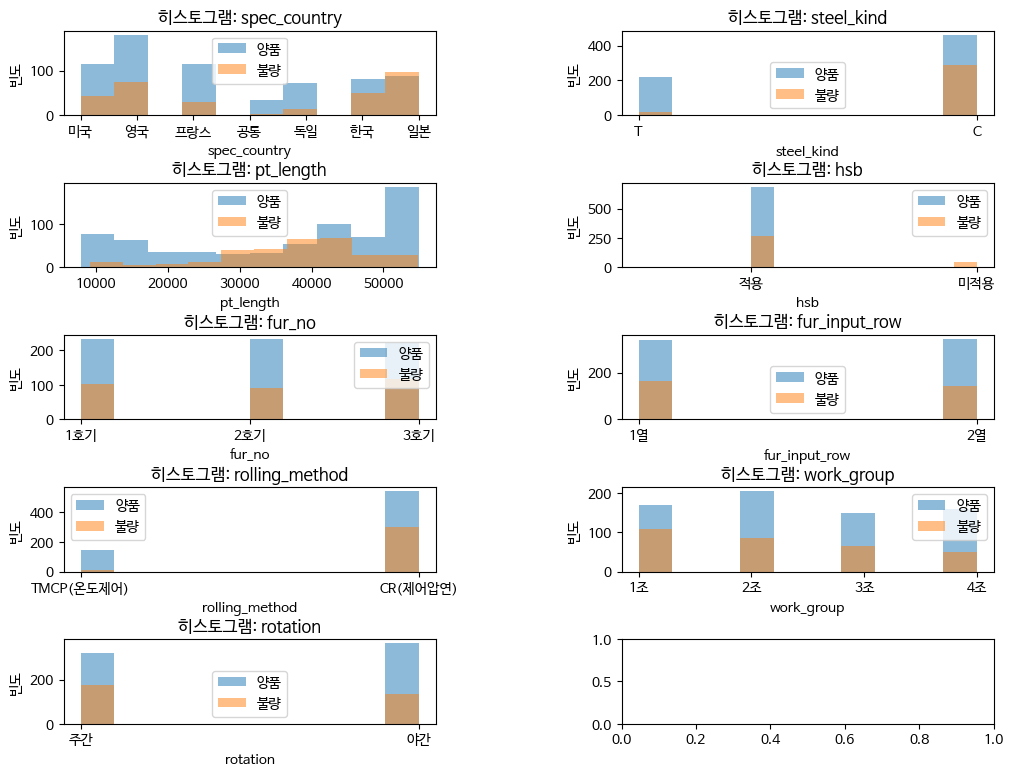

In [ ]:
#범주형 변수 그리기
fig, axs = plt.subplots(5, 2, figsize=(12, 9))
axs = axs.flatten()

plot_hist(df_raw, "spec_country", ax=axs[0])
plot_hist(df_raw, "steel_kind", ax=axs[1])
plot_hist(df_raw, "pt_length", ax=axs[2]);
plot_hist(df_raw, "hsb", ax=axs[3]);
plot_hist(df_raw, "fur_no", ax=axs[4]);
plot_hist(df_raw, "fur_input_row", ax=axs[5]);
plot_hist(df_raw, "rolling_method", ax=axs[6]);
plot_hist(df_raw, "work_group", ax=axs[7]);
plot_hist(df_raw, "rotation", ax=axs[8])



fig.subplots_adjust(wspace=0.5, hspace=0.8)
plt.show()

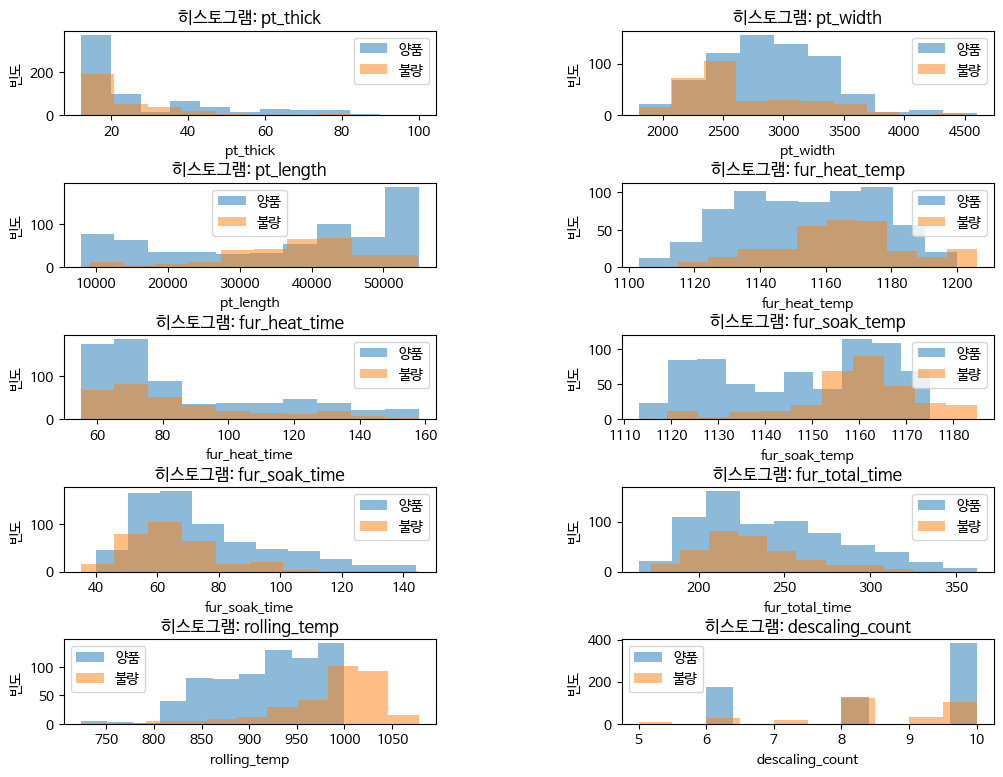

In [ ]:
#연속형 변수 그리기
fig, axs = plt.subplots(5, 2, figsize=(12, 9))
axs = axs.flatten()

plot_hist(df_raw, "pt_thick", ax=axs[0])
plot_hist(df_raw, "pt_width", ax=axs[1])
plot_hist(df_raw, "pt_length", ax=axs[2]);
plot_hist(df_raw, "fur_heat_temp", ax=axs[3]);
plot_hist(df_raw, "fur_heat_time", ax=axs[4]);
plot_hist(df_raw, "fur_soak_temp", ax=axs[5]);
plot_hist(df_raw, "fur_soak_time", ax=axs[6]);
plot_hist(df_raw, "fur_total_time", ax=axs[7]);
plot_hist(df_raw, "rolling_temp", ax=axs[8])
plot_hist(df_raw, "descaling_count", ax=axs[9])


fig.subplots_adjust(wspace=0.5, hspace=0.8)
plt.show()

목표변수와 설명변수(범주형) 간 교차표

In [ ]:
def print_crosstab(data, var):
    print(pd.crosstab(index = data["scale"], columns = data[var]))
    print()
    print(pd.crosstab(index = data["scale"], columns = data[var], normalize = "columns").round(3))

In [ ]:
print_crosstab(df_raw, "spec_long") #제품규격

spec_long  A131-DH36TM  A283-C  A516-60  A709-36  AB/A  AB/AH32  AB/B  \
scale                                                                   
불량                   1       5        2        0    13        8     3   
양품                   0       1        1        1    38       23     6   

spec_long  AB/EH32-TM  AB/EH36-TM  API-2W-50T  ...  NV-A32-TM  NV-A36-TM  \
scale                                          ...                         
불량                  0           2           0  ...          1          0   
양품                  2          30           2  ...          2          2   

spec_long  NV-B  NV-D32-TM  NV-D36-TM  NV-E32-TM  NV-E36-TM  PILAC-BT33  \
scale                                                                     
불량            2          0          1          0          0           2   
양품            1          3          4          2          5          36   

spec_long  SA283-C  V42JBN3  
scale                        
불량              10        1  
양품         

In [ ]:
print_crosstab(df_raw, "spec_country") #제품 규격 기준국

spec_country  공통  독일   미국   영국  일본  프랑스  한국
scale                                      
불량             3  13   44   75  97   29  49
양품            33  73  115  180  88  114  81

spec_country     공통     독일     미국     영국     일본    프랑스     한국
scale                                                        
불량            0.083  0.151  0.277  0.294  0.524  0.203  0.377
양품            0.917  0.849  0.723  0.706  0.476  0.797  0.623


In [ ]:
print_crosstab(df_raw, "fur_input_row") #가열로 장입열

fur_input_row   1열   2열
scale                  
불량             165  145
양품             340  344

fur_input_row     1열     2열
scale                      
불량             0.327  0.297
양품             0.673  0.703


In [ ]:
print_crosstab(df_raw, "steel_kind") #강종 (C:탄소강  T:티타늄강)

steel_kind    C    T
scale               
불량          290   20
양품          463  221

steel_kind      C      T
scale                   
불량          0.385  0.083
양품          0.615  0.917


In [ ]:
print_crosstab(df_raw, "hsb") #Hot Scale  Braker 적용 여부

hsb    미적용   적용
scale          
불량      47  263
양품       0  684

hsb    미적용     적용
scale            
불량     1.0  0.278
양품     0.0  0.722


In [ ]:
print_crosstab(df_raw, "fur_no") # 가열로 호기

fur_no  1호기  2호기  3호기
scale                
불량      101   92  117
양품      231  232  221

fur_no    1호기    2호기    3호기
scale                      
불량      0.304  0.284  0.346
양품      0.696  0.716  0.654


In [ ]:
print_crosstab(df_raw, "rolling_method") # 압연 방법

rolling_method  CR(제어압연)  TMCP(온도제어)
scale                               
불량                   297          13
양품                   539         145

rolling_method  CR(제어압연)  TMCP(온도제어)
scale                               
불량                 0.355       0.082
양품                 0.645       0.918


In [ ]:
print_crosstab(df_raw, "work_group") # 작업조

work_group   1조   2조   3조   4조
scale                         
불량          109   85   66   50
양품          170  205  149  160

work_group     1조     2조     3조     4조
scale                                 
불량          0.391  0.293  0.307  0.238
양품          0.609  0.707  0.693  0.762


In [ ]:
print_crosstab(df_raw, "rotation") # 교대

rotation   야간   주간
scale             
불량        135  175
양품        365  319

rotation    야간     주간
scale                
불량        0.27  0.354
양품        0.73  0.646


scale 변수 형변환

In [ ]:
df_raw["scale"].replace(to_replace = "양품", value = 0, inplace = True)
df_raw["scale"].replace(to_replace = "불량", value = 1, inplace = True)
df_raw["scale"].head()

0    0
1    0
2    0
3    0
4    0
Name: scale, dtype: int64

In [ ]:
df_corr = df_raw.corr()
df_corr

,scale,pt_thick,pt_width,pt_length,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_temp,descaling_count
scale,1.000000,-0.094441,-0.193817,0.048928,0.220581,-0.036178,0.326957,-0.220873,-0.129333,0.511333,-0.043415
pt_thick,-0.094441,1.000000,-0.320606,-0.866691,-0.522101,0.205822,-0.663015,0.363622,0.343731,-0.450942,-0.845154
pt_width,-0.193817,-0.320606,1.000000,0.148769,0.201312,-0.103698,0.218066,-0.101242,-0.137791,-0.155038,0.353954
pt_length,0.048928,-0.866691,0.148769,1.000000,0.466737,-0.135821,0.599513,-0.336363,-0.278400,0.366254,0.816850
fur_heat_temp,0.220581,-0.522101,0.201312,0.466737,1.000000,-0.161504,0.785440,-0.375056,-0.314602,0.341403,0.483688
fur_heat_time,-0.036178,0.205822,-0.103698,-0.135821,-0.161504,1.000000,-0.347486,0.114218,0.736399,-0.131929,-0.163866
fur_soak_temp,0.326957,-0.663015,0.218066,0.599513,0.785440,-0.347486,1.000000,-0.601144,-0.564089,0.628510,0.623454
fur_soak_time,-0.220873,0.363622,-0.101242,-0.336363,-0.375056,0.114218,-0.601144,1.000000,0.632780,-0.486545,-0.402145
fur_total_time,-0.129333,0.343731,-0.137791,-0.278400,-0.314602,0.736399,-0.564089,0.632780,1.000000,-0.345276,-0.340797
rolling_temp,0.511333,-0.450942,-0.155038,0.366254,0.341403,-0.131929,0.628510,-0.486545,-0.345276,1.000000,0.313695


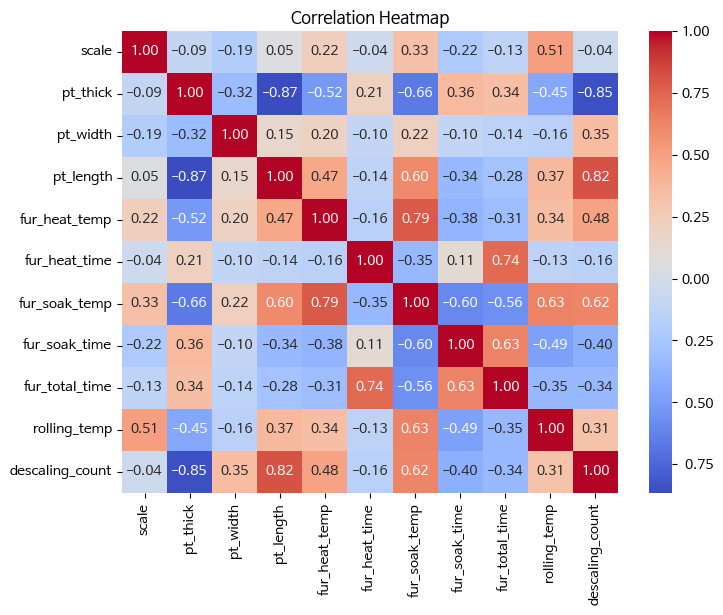

In [ ]:
#히트맵
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

히트맵 결과,
scale과 상관관계가 높은 변수는 rolling_temp(0.51)로 양의 상관관계를 가지고 있으며 그 다음으로는 0.33 양의 상관관계를 갖고 있는 fur_soak_temp 이다.

# 로지스틱 회귀

데이터 분할

In [ ]:
# 데이터 분할:train, test
from sklearn.model_selection import train_test_split


df_train, df_test = train_test_split(df_raw, # 데이터
                                     test_size = 0.2, # test 데이터의 비율
                                     random_state = 1234)  # random state

print("train data size : {}".format(df_train.shape))
print("test data size : {}".format(df_test.shape))

train data size : (795, 20)
test data size : (199, 20)


In [ ]:
# 명목형 변수 목록
obj_cols = df_raw.select_dtypes("object").columns

for col in obj_cols:
    _n = len(df_raw[col].value_counts())
    print(col, ":", str(_n))

spec_long : 66
spec_country : 7
steel_kind : 2
hsb : 2
fur_no : 3
fur_input_row : 2
rolling_method : 2
work_group : 4
rotation : 2


In [ ]:
#spec_long, spec_country : 범주화 종류가 많아서 제외함
log_model = sm.Logit.from_formula("""scale  ~ C(steel_kind)+ pt_thick + pt_width + pt_length  + C(fur_no) +
                                   C(fur_input_row) +fur_heat_temp + fur_heat_time + fur_soak_temp + fur_soak_time +
                                  fur_total_time  + rolling_temp + C(rolling_method) + C(hsb) + descaling_count + C(work_group)+ C(rotation) """ ,
                                  df_train)

# 적합
log_result = log_model.fit()
# 결과 출력
print(log_result.summary())

         Current function value: 0.302410
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                  scale   No. Observations:                  795
Model:                          Logit   Df Residuals:                      775
Method:                           MLE   Df Model:                           19
Date:                Tue, 12 Mar 2024   Pseudo R-squ.:                  0.5180
Time:                        05:41:51   Log-Likelihood:                -240.42
converged:                      False   LL-Null:                       -498.81
Covariance Type:            nonrobust   LLR p-value:                 1.667e-97
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                         -47.7710   8.18e+06  -5.84e-06      1.000    -1.6e+07     1.6e+07
C(

/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


모델의 Pseudo R-squared 값은 약 0.5180로, 설명변수들이 종속변수를 약 51.80% 정도 설명한다고 해석할 수 있다.  
p-value값이 유의한 변수만 뽑아 다시 로지스틱 회귀 돌림

In [ ]:
log_model = sm.Logit.from_formula("""scale  ~ pt_width + pt_length +fur_heat_temp + fur_heat_time+
                                    rolling_temp  + descaling_count """ ,
                                  df_train)

# 적합
log_result = log_model.fit()
# 결과 출력
print(log_result.summary())

Optimization terminated successfully.
         Current function value: 0.417884
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  scale   No. Observations:                  795
Model:                          Logit   Df Residuals:                      788
Method:                           MLE   Df Model:                            6
Date:                Tue, 12 Mar 2024   Pseudo R-squ.:                  0.3340
Time:                        02:02:51   Log-Likelihood:                -332.22
converged:                       True   LL-Null:                       -498.81
Covariance Type:            nonrobust   LLR p-value:                 6.257e-69
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         -57.0919      7.037     -8.113      0.000     -70.885     -43.299
pt_width      

0.33의 설명력을 가지고 있고, pt_width, pt_length, fur_heat_time은 유의하지 않아 빼고 회귀분석 돌림

In [ ]:
log_model = sm.Logit.from_formula("""scale  ~ fur_heat_temp+ rolling_temp+descaling_count """ ,
                                  df_train)

# 적합
log_result = log_model.fit()
# 결과 출력
print(log_result.summary())

Optimization terminated successfully.
         Current function value: 0.421315
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  scale   No. Observations:                  795
Model:                          Logit   Df Residuals:                      791
Method:                           MLE   Df Model:                            3
Date:                Tue, 12 Mar 2024   Pseudo R-squ.:                  0.3285
Time:                        05:41:55   Log-Likelihood:                -334.95
converged:                       True   LL-Null:                       -498.81
Covariance Type:            nonrobust   LLR p-value:                 9.874e-71
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         -53.9853      6.629     -8.143      0.000     -66.979     -40.992
fur_heat_temp 

회귀계수가 유의한 것만 뽑은 결과, 32% 설명함

In [ ]:
#train 데이터 예측  -> y_pred_train
y_pred_train = log_result.predict(df_train)
# 0과 1의  class로 변환
y_pred_train_class = (y_pred_train > 0.5).astype(int)  # 0.5 : “1/0” 판정 임계값(1 발생 확률) 변경 가능
print("Train 예측 결과 \n", y_pred_train_class.head(), "\n")
print("Confusion Matrix: \n{}".format(confusion_matrix(df_train["scale"],y_pred_train_class)),"\n")

# test 데이터 예측
y_pred_test = log_result.predict(df_test)
# 0과 1의  class로 변환
y_pred_test_class = (y_pred_test > 0.5).astype(int)
print("Test 예측 결과 \n", y_pred_test_class.head(),"\n")
print("Confusion Matrix: \n{}".format(confusion_matrix(df_test["scale"],y_pred_test_class)),"\n")

Train 예측 결과 
 284    1
789    0
229    0
62     0
397    0
dtype: int64 

Confusion Matrix: 
[[486  54]
 [ 82 173]] 

Test 예측 결과 
 771    1
986    0
953    0
783    0
203    1
dtype: int64 

Confusion Matrix: 
[[132  12]
 [ 23  32]] 



In [ ]:
# 실제 train 데이터와 예측 결과 비교
print("Train 예측/분류 결과")
print("Accuracy: {0:.3f}\n".format(accuracy_score(df_train["scale"], y_pred_train_class)))
print("Confusion Matrix: \n{}".format(confusion_matrix(df_train["scale"],y_pred_train_class)),"\n")
print(classification_report(df_train["scale"], y_pred_train_class, digits=3))

# 실제 train 데이터와 예측 결과 비교
print("Test 예측/분류 결과")
print("Accuracy: {0:.3f}\n".format(accuracy_score(df_test["scale"], y_pred_test_class)))
print("Confusion Matrix: \n{}".format(confusion_matrix(df_test["scale"],y_pred_test_class)),"\n")
print(classification_report(df_test["scale"], y_pred_test_class, digits=3))

Train 예측/분류 결과
Accuracy: 0.829

Confusion Matrix: 
[[486  54]
 [ 82 173]] 

              precision    recall  f1-score   support

           0      0.856     0.900     0.877       540
           1      0.762     0.678     0.718       255

    accuracy                          0.829       795
   macro avg      0.809     0.789     0.798       795
weighted avg      0.826     0.829     0.826       795

Test 예측/분류 결과
Accuracy: 0.824

Confusion Matrix: 
[[132  12]
 [ 23  32]] 

              precision    recall  f1-score   support

           0      0.852     0.917     0.883       144
           1      0.727     0.582     0.646        55

    accuracy                          0.824       199
   macro avg      0.789     0.749     0.765       199
weighted avg      0.817     0.824     0.818       199



In [ ]:
# f1 score로 모델 평가
print("Train 예측/분류 결과")

print(classification_report(df_test["scale"], y_pred_test_class, target_names=['양품', '불량'], digits=3))

print("Test 예측/분류 결과")
#  f1 score로 모델 평가

print(classification_report(df_test["scale"], y_pred_test_class, target_names=['양품', '불량'], digits=3))

Train 예측/분류 결과
              precision    recall  f1-score   support

          양품      0.852     0.917     0.883       144
          불량      0.727     0.582     0.646        55

    accuracy                          0.824       199
   macro avg      0.789     0.749     0.765       199
weighted avg      0.817     0.824     0.818       199

Test 예측/분류 결과
              precision    recall  f1-score   support

          양품      0.852     0.917     0.883       144
          불량      0.727     0.582     0.646        55

    accuracy                          0.824       199
   macro avg      0.789     0.749     0.765       199
weighted avg      0.817     0.824     0.818       199



f1 score 모델 평가 결과, test 데이터에서 f1 score 는 0824, recall 값은 0.58
로 상대적으로 낮은 편이다.

<Axes: >

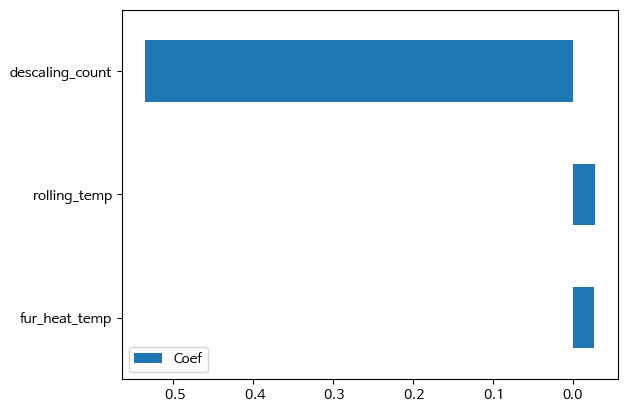

In [ ]:
# 설명변수 중요도
df_logistic_coef = pd.DataFrame({"Coef": log_result.params.values[1:]}, index = log_model.exog_names[1:])
df_logistic_coef.plot.barh(y = "Coef")


로지스틱 회귀 분류 결과 descaling_count이 불량 검출에 큰 영향을 준다고 추정할 수 있다. 그리고 작업조 3조에서 불량 검출이 나올 가능성도 크다고 추정할 수 있다.

In [ ]:
# 로지스틱 모델로 test 데이터 예측
y_pred = log_result.predict(df_test)
# 0과 1의 값을 가진 class로 변환
y_pred_class = (y_pred > 0.5).astype(int)
# 상위 10건 출력
y_pred_class.head(10)

771    1
986    0
953    0
783    0
203    1
854    0
310    0
620    0
125    0
147    0
dtype: int64

In [ ]:
#성능지표 만드는 함수
def metbin(y, yh, ph=None, modelname=None):
    tn, fp, fn, tp = confusion_matrix(y, yh).ravel()
    acc    = accuracy_score(y, yh)

    f1     = f1_score(y, yh)                  # (sens, prec)간 조화평균
    #balacc = balanced_accuracy_score(y, yh)   # (sens+spec)/2


    # theshold=0.5일때 tn, fp, fn, tp로 직접 계산
    sens = tp/(tp+fn)  # recall_score(y, yhsvm)
    spec = tn/(tn+fp)
    prec = tp/(tp+fp)  # precision_score(y, yh)
    #iba  = (1+0.1*(sens-spec))*sens*spec   # alpha=0.1일때 index of balanced accuracy
    gmean  = np.sqrt(sens*spec) # geometric_mean_score(y, yh) # sqrt(sens*spec). G-mean2는 sqrt(sens*prec)

    if ph is not None:

        metrics =  {'acc' :acc, 'sens':sens,    'spec':spec,     'prec':prec,
                    'gmean':gmean, 'f1'  :f1,
                    'tn'  :tn,  'fp'  :fp,      'fn'  :fn,       'tp'  :tp}
    else:
        metrics = {'acc' :acc, 'sens':sens,    'spec':spec,     'prec':prec,
                    'gmean':gmean, 'f1'  :f1,
                    'tn'  :tn,  'fp'  :fp,      'fn'  :fn,       'tp'  :tp}
    if modelname is not None:
        return pd.DataFrame(metrics, index=[modelname])
    return metrics

In [ ]:
# Train 데이터셋에 대한 성능 지표 저장
train_metrics = metbin(df_train["scale"], y_pred_train_class, modelname='Logistic')

# Test 데이터셋에 대한 성능 지표 저장
test_metrics = metbin(df_test["scale"], y_pred_test_class, modelname='Logistic')


In [ ]:
test_metrics

,acc,sens,spec,prec,gmean,f1,tn,fp,fn,tp
Logistic,0.824121,0.581818,0.916667,0.727273,0.730297,0.646465,132,12,23,32


표준화 회귀 계수 로지스틱 회귀분석

In [ ]:
df_char = df_raw.select_dtypes(include = "object")
df_numeric = df_raw.select_dtypes(exclude = "object")

# Data Scaling
scaler = StandardScaler()
np_numeric_scaled = scaler.fit_transform(df_numeric)
df_numeric_scaled = pd.DataFrame(np_numeric_scaled, columns = df_numeric.columns)

# 문자 데이터 + 숫자 데이터
df_scaled = pd.concat([df_numeric_scaled, df_char],axis = 1)
df_scaled.head()

,scale,pt_thick,pt_width,pt_length,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_temp,descaling_count,spec_long,spec_country,steel_kind,hsb,fur_no,fur_input_row,rolling_method,work_group,rotation
0,-0.673213,0.297380,1.758916,-1.568542,-0.629006,1.138138,-1.042290,-0.617512,0.531891,-0.098376,-0.353037,AB/EH32-TM,미국,T,적용,1호기,1열,TMCP(온도제어),1조,주간
1,-0.673213,0.297380,1.758916,-1.568542,-0.629006,1.365628,-0.926564,-0.908186,-0.017312,-0.051371,-0.353037,AB/EH32-TM,미국,T,적용,1호기,2열,TMCP(온도제어),1조,주간
2,-0.673213,0.352984,1.555807,-1.273013,-1.336122,1.138138,-1.736646,-0.811295,0.505738,-0.803452,-0.353037,NV-E36-TM,영국,T,적용,2호기,1열,TMCP(온도제어),1조,주간
3,-0.673213,0.352984,1.555807,-1.273013,-0.251878,1.479374,-1.389468,-0.181501,0.714959,-0.866125,-0.353037,NV-E36-TM,영국,T,적용,2호기,2열,TMCP(온도제어),1조,주간
4,-0.673213,0.631008,0.540262,-1.698287,-0.817571,1.820609,-1.331605,-1.150415,0.191908,-1.054145,-0.353037,BV-EH36-TM,프랑스,T,적용,3호기,1열,TMCP(온도제어),1조,주간


In [ ]:
#스케일링 한 scale 변수는 0과 1로 변환
df_scaled["scale"] = np.where(df_scaled["scale"]> 0, 1, 0)
df_scaled.head()

,scale,pt_thick,pt_width,pt_length,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_temp,descaling_count,spec_long,spec_country,steel_kind,hsb,fur_no,fur_input_row,rolling_method,work_group,rotation
0,0,0.297380,1.758916,-1.568542,-0.629006,1.138138,-1.042290,-0.617512,0.531891,-0.098376,-0.353037,AB/EH32-TM,미국,T,적용,1호기,1열,TMCP(온도제어),1조,주간
1,0,0.297380,1.758916,-1.568542,-0.629006,1.365628,-0.926564,-0.908186,-0.017312,-0.051371,-0.353037,AB/EH32-TM,미국,T,적용,1호기,2열,TMCP(온도제어),1조,주간
2,0,0.352984,1.555807,-1.273013,-1.336122,1.138138,-1.736646,-0.811295,0.505738,-0.803452,-0.353037,NV-E36-TM,영국,T,적용,2호기,1열,TMCP(온도제어),1조,주간
3,0,0.352984,1.555807,-1.273013,-0.251878,1.479374,-1.389468,-0.181501,0.714959,-0.866125,-0.353037,NV-E36-TM,영국,T,적용,2호기,2열,TMCP(온도제어),1조,주간
4,0,0.631008,0.540262,-1.698287,-0.817571,1.820609,-1.331605,-1.150415,0.191908,-1.054145,-0.353037,BV-EH36-TM,프랑스,T,적용,3호기,1열,TMCP(온도제어),1조,주간


In [ ]:
# 데이터 분할
df_scaled_train, df_scaled_test = train_test_split(df_scaled, # 데이터
                               test_size = 0.2, # test 데이터의 비율
                               random_state = 1234)  # random state

In [ ]:
#표준화하고 로지스틱회귀분석
scaled_log_model = Logit.from_formula("""scale  ~ C(steel_kind)+ pt_thick + pt_width + pt_length  + C(fur_no) +
                                   C(fur_input_row) +fur_heat_temp + fur_heat_time + fur_soak_temp + fur_soak_time +
                                  fur_total_time  + rolling_temp + C(rolling_method) + C(hsb) + descaling_count + C(work_group)+ C(rotation)""", df_scaled_train)
# 적합
scaled_log_result = scaled_log_model.fit()
# 결과 출력
print(scaled_log_result.summary())

Optimization terminated successfully.
         Current function value: 0.383558
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  scale   No. Observations:                  789
Model:                          Logit   Df Residuals:                      769
Method:                           MLE   Df Model:                           19
Date:                Tue, 12 Mar 2024   Pseudo R-squ.:                  0.3735
Time:                        05:42:24   Log-Likelihood:                -302.63
converged:                       True   LL-Null:                       -483.07
Covariance Type:            nonrobust   LLR p-value:                 5.734e-65
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -1.3763   6.76e+06  -2.04e-07  

설명변수 표준화하고 로지스틱 회귀분석 한 결과 37%의 설명력을 갖고 있다.   
steel_kind, fur_no, pt_width, fur_heat_temp,  rolling_temp, descaling_count  가 나옴

In [ ]:
# 유의하다고 선정된 설명변수 기준
scaled_log_model = Logit.from_formula("""scale  ~ C(steel_kind) + pt_width + C(fur_no)
                                   +fur_heat_temp
                                    + rolling_temp  + descaling_count """, df_scaled_train)
# 적합
scaled_log_result = scaled_log_model.fit()
# 결과 출력
print(scaled_log_result.summary())

Optimization terminated successfully.
         Current function value: 0.396847
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  scale   No. Observations:                  789
Model:                          Logit   Df Residuals:                      781
Method:                           MLE   Df Model:                            7
Date:                Tue, 12 Mar 2024   Pseudo R-squ.:                  0.3518
Time:                        05:42:29   Log-Likelihood:                -313.11
converged:                       True   LL-Null:                       -483.07
Covariance Type:            nonrobust   LLR p-value:                 1.777e-69
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -1.2013      0.241     -4.987      0.000      -1.673      -0.729
C(ste

최종 표준화 로지스틱 회귀분석 모델은 0.35 의 설명력을 가지고 있고 , 모든 계수가 회귀계수에서 유의하다.

In [ ]:
y_pred_train = scaled_log_result.predict(df_scaled_train)
# 0과 1의 값을 가진 class로 변환
y_pred_train_class = (y_pred_train > 0.5).astype(int)  # 0.5 : “1/0” 판정 임계값(1 발생 확률) 변경 가능
print("Train 예측 결과 \n", y_pred_train_class.head(), "\n")
print("Confusion Matrix: \n{}".format(confusion_matrix(df_scaled_train["scale"],y_pred_train_class)),"\n")

# test 데이터 예측
y_pred_test = scaled_log_result.predict(df_scaled_test)
# 0과 1의 값을 가진 class로 변환
y_pred_test_class = (y_pred_test > 0.5).astype(int)
print("Test 예측 결과 \n", y_pred_test_class.head(),"\n")
print("Confusion Matrix: \n{}".format(confusion_matrix(df_scaled_test["scale"],y_pred_test_class)),"\n")

Train 예측 결과 
 281    0
42     0
255    1
906    1
394    0
dtype: int64 

Confusion Matrix: 
[[520  42]
 [ 86 152]] 

Test 예측 결과 
 681    0
990    0
155    0
768    0
438    0
dtype: int64 

Confusion Matrix: 
[[121   7]
 [ 36  36]] 



In [ ]:
#f1 score로 모델 평가
print("Train 예측/분류 결과")
print(classification_report(df_scaled_train["scale"], y_pred_train_class, target_names=['양품', '불량'], digits=3))

print("Test 예측/분류 결과")
# f1 score로 모델 평가

print(classification_report(df_scaled_test["scale"], y_pred_test_class, target_names=['양품', '불량'], digits=3))

Train 예측/분류 결과
              precision    recall  f1-score   support

          양품      0.858     0.925     0.890       562
          불량      0.784     0.639     0.704       238

    accuracy                          0.840       800
   macro avg      0.821     0.782     0.797       800
weighted avg      0.836     0.840     0.835       800

Test 예측/분류 결과
              precision    recall  f1-score   support

          양품      0.771     0.945     0.849       128
          불량      0.837     0.500     0.626        72

    accuracy                          0.785       200
   macro avg      0.804     0.723     0.738       200
weighted avg      0.795     0.785     0.769       200



목표변수의 빈도 불균형 때문에 정확도 대신 f1 score로 모델의 정확성을 판단.  
표준화한 결과 test 데이터의  f1 score는  0.785 이고 불량률 검출에 대한 재현율은 0.500로 다소 낮은 편이다

In [ ]:
train_metrics = pd.concat([train_metrics, metbin(df_scaled_train["scale"], y_pred_train_class, modelname='scaledLogistic')])
test_metrics = pd.concat([test_metrics, metbin(df_scaled_test["scale"], y_pred_test_class, modelname='scaledLogistic')])


In [ ]:
test_metrics

,acc,sens,spec,prec,gmean,f1,tn,fp,fn,tp
Logistic,0.824121,0.581818,0.916667,0.727273,0.730297,0.646465,132,12,23,32
scaledLogistic,0.785000,0.500000,0.945312,0.837209,0.687500,0.626087,121,7,36,36


In [ ]:
train_metrics

,acc,sens,spec,prec,gmean,f1,tn,fp,fn,tp
Logistic,0.828931,0.678431,0.900000,0.762115,0.781401,0.717842,486,54,82,173
scaledLogistic,0.840000,0.638655,0.925267,0.783505,0.768718,0.703704,520,42,86,152


<Axes: >

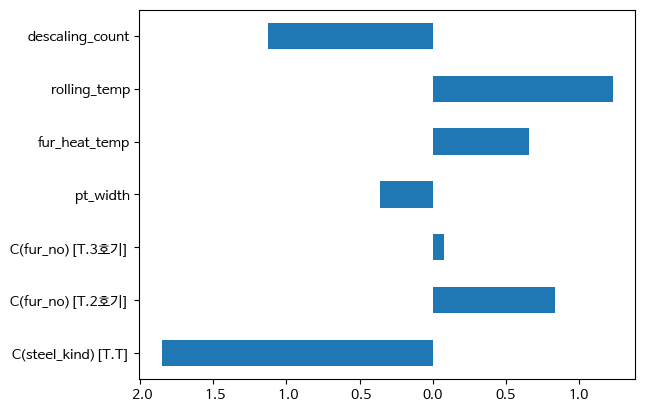

In [ ]:
# 설명변수 중요도
df_log_scaled_coef = pd.DataFrame({"Coef": scaled_log_result.params.values[1:]}, index = scaled_log_model.exog_names[1:])
df_log_scaled_coef.plot.barh(y = "Coef", legend = False)

## 결론
표준화한 변수를 로지스틱 회귀분석한 결과 불량률 예측해서 가장 많은 영향을 주는 변수는 압연온도, 압연descaling 횟수,  가열로가열대 소재온도, work_group 순으로 높은 것을 알 수 있다.

# 의사결정나무

In [ ]:
df_raw

,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,fur_no,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group,rotation
0,0,AB/EH32-TM,미국,T,32,3700,15100,적용,1호기,1열,1144,116,1133,59,259,TMCP(온도제어),934,8,1조,주간
1,0,AB/EH32-TM,미국,T,32,3700,15100,적용,1호기,2열,1144,122,1135,53,238,TMCP(온도제어),937,8,1조,주간
2,0,NV-E36-TM,영국,T,33,3600,19200,적용,2호기,1열,1129,116,1121,55,258,TMCP(온도제어),889,8,1조,주간
3,0,NV-E36-TM,영국,T,33,3600,19200,적용,2호기,2열,1152,125,1127,68,266,TMCP(온도제어),885,8,1조,주간
4,0,BV-EH36-TM,프랑스,T,38,3100,13300,적용,3호기,1열,1140,134,1128,48,246,TMCP(온도제어),873,8,1조,주간
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,BV-A,프랑스,C,19,3400,41500,적용,1호기,2열,1142,55,1151,86,203,CR(제어압연),948,10,4조,야간
996,0,LR-A,영국,C,19,3400,41500,적용,1호기,2열,1142,55,1151,86,209,CR(제어압연),948,10,4조,야간
997,0,AB/AH32,미국,C,17,3400,43700,적용,2호기,2열,1169,65,1163,77,227,CR(제어압연),948,10,4조,야간
998,0,NV-A32,영국,C,17,3400,43700,적용,2호기,2열,1169,65,1163,77,204,CR(제어압연),948,10,4조,야간


설명변수 더미화

In [ ]:
df_char = df_raw.select_dtypes(include = "object")
df_numeric = df_raw.select_dtypes(exclude = "object")

df_dummy = pd.get_dummies(df_char)


# 더미화된 문자 데이터 + 숫자 데이터
df_scaled = pd.concat([df_numeric, df_dummy],axis = 1)
df_scaled.head()

,scale,pt_thick,pt_width,pt_length,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_temp,...,fur_input_row_1열,fur_input_row_2열,rolling_method_CR(제어압연),rolling_method_TMCP(온도제어),work_group_1조,work_group_2조,work_group_3조,work_group_4조,rotation_야간,rotation_주간
0,0,32,3700,15100,1144,116,1133,59,259,934,...,1,0,0,1,1,0,0,0,0,1
1,0,32,3700,15100,1144,122,1135,53,238,937,...,0,1,0,1,1,0,0,0,0,1
2,0,33,3600,19200,1129,116,1121,55,258,889,...,1,0,0,1,1,0,0,0,0,1
3,0,33,3600,19200,1152,125,1127,68,266,885,...,0,1,0,1,1,0,0,0,0,1
4,0,38,3100,13300,1140,134,1128,48,246,873,...,1,0,0,1,1,0,0,0,0,1


df_scaled에 x,y분할

In [ ]:
df_scaled_x = df_scaled.drop('scale', axis = 1)
df_scaled_y = df_scaled['scale']

In [ ]:
#데이터 분할

X_train, X_test, y_train, y_test = train_test_split(df_scaled_x, df_scaled_y, test_size = 0.2, random_state = 1234)

In [ ]:
model = DecisionTreeClassifier()
param_grid = {"criterion": ["gini", "entropy"],
              "max_depth": [depth for depth in range(2, 5)],
              "min_samples_split": [sample_split for sample_split in range(2, 31)],
              "min_samples_leaf": [sample_leaf for sample_leaf in range(2, 11)]}

grid_dt = GridSearchCV(model, param_grid, scoring="accuracy", n_jobs = -1)
grid_dt.fit(X_train, y_train)

print("best estimator model: \n{}".format(grid_dt.best_estimator_))
print("\nbest parameter: \n{}".format(grid_dt.best_params_))
print("\nbest score: \n{}".format(grid_dt.best_score_.round(3)))

best estimator model: 
DecisionTreeClassifier(max_depth=4, min_samples_leaf=2)

best parameter: 
{'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}

best score: 
0.962


gridsearch를 통해 최적의 파라미터를 찾고 최종 의사결정트리 모델에 적용

In [ ]:
#최종 모형 생성
dt_final = DecisionTreeClassifier(criterion = "gini", max_depth = 4, min_samples_leaf = 2, min_samples_split = 2)
dt_final.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=2)

In [ ]:
# 설명변수 중요도 확인
feature_importance = pd.DataFrame()
feature_importance["feature"] = X_train.columns
feature_importance["importance"] = dt_final.feature_importances_
feature_importance.sort_values(by="importance", ascending=False)

,feature,importance
8,rolling_temp,0.619559
85,hsb_미적용,0.176601
5,fur_soak_temp,0.167134
9,descaling_count,0.036706
0,pt_thick,0.000000
...,...,...
33,spec_long_GL-A36-TM,0.000000
32,spec_long_GL-A32-TM,0.000000
31,spec_long_GL-A32,0.000000
30,spec_long_GL-A,0.000000


의사결정트리를 사용하여 후판공정 불량률을 분류했을 때, 가장 영향을 많이 주는 변수로 rolling_temp, hsb_미적용, fur_soak_temp로 나타났다.

In [ ]:
# 의결트  모델로 test 데이터 예측
y_pred_test = dt_final.predict(X_test)
y_pred_test

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0])

In [ ]:
y_pred_train = dt_final.predict(X_train)
y_pred_train

array([1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,

In [ ]:
train_metrics = pd.concat([train_metrics, metbin(df_train["scale"], y_pred_train, modelname='DT')])
test_metrics = pd.concat([test_metrics, metbin(df_test["scale"], y_pred_test, modelname='DT')])


In [ ]:
test_metrics

,acc,sens,spec,prec,gmean,f1,tn,fp,fn,tp
Logistic,0.824121,0.581818,0.916667,0.727273,0.730297,0.646465,132,12,23,32
scaledLogistic,0.785000,0.500000,0.945312,0.837209,0.687500,0.626087,121,7,36,36
DT,0.974874,0.909091,1.000000,1.000000,0.953463,0.952381,144,0,5,50


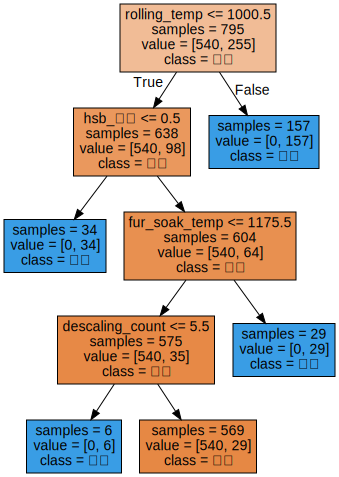

In [ ]:
# 트리 모델을 tree.dot 파일로 저장
export_graphviz(dt_final, out_file="tree.dot", class_names= ["양품", "불량"],
                feature_names = X_train.columns, impurity=False, filled=True)

# graphviz를 이용해 트리 모델 시각화
with open("tree.dot", "rt", encoding="utf-8") as f:
    dot_graph = f.read()
display(graphviz.Source(dot_graph))

# Random Forest

In [ ]:
model = RandomForestClassifier()
param_grid = {"criterion": ["gini", "entropy"],
              "max_depth": [depth for depth in range(3, 11)],
              "min_samples_leaf": [sample_leaf for sample_leaf in range(10, 21)]}

grid_dt = GridSearchCV(model, param_grid, scoring="accuracy", n_jobs = -1)
grid_dt.fit(X_train, y_train)

print("best estimator model: \n{}".format(grid_dt.best_estimator_))
print("\nbest parameter: \n{}".format(grid_dt.best_params_))
print("\nbest score: \n{}".format(grid_dt.best_score_.round(3)))

best estimator model: 
RandomForestClassifier(max_depth=9, min_samples_leaf=10)

best parameter: 
{'criterion': 'gini', 'max_depth': 9, 'min_samples_leaf': 10}

best score: 
0.909


gridsearch를 통해 최적의 파라미터를 찾고 최종 모델에 적용함.

In [ ]:
rf_final = RandomForestClassifier(criterion = "gini", max_depth = 9, min_samples_leaf = 10)
rf_final.fit(X_train, y_train)

RandomForestClassifier(max_depth=9, min_samples_leaf=10)

In [ ]:
#설명변수 중요도 확인
feature_importance = pd.DataFrame()
feature_importance["feature"] = X_train.columns
feature_importance["importance"] = rf_final.feature_importances_
feature_importance.sort_values(by="importance", ascending=False)

,feature,importance
8,rolling_temp,0.281996
1,pt_width,0.095251
5,fur_soak_temp,0.091593
0,pt_thick,0.078859
2,pt_length,0.064640
...,...,...
60,spec_long_NK-KA,0.000000
26,spec_long_BV-EH32-TM,0.000000
63,spec_long_NK-KD36-TM,0.000000
66,spec_long_NV-A32-TM,0.000000


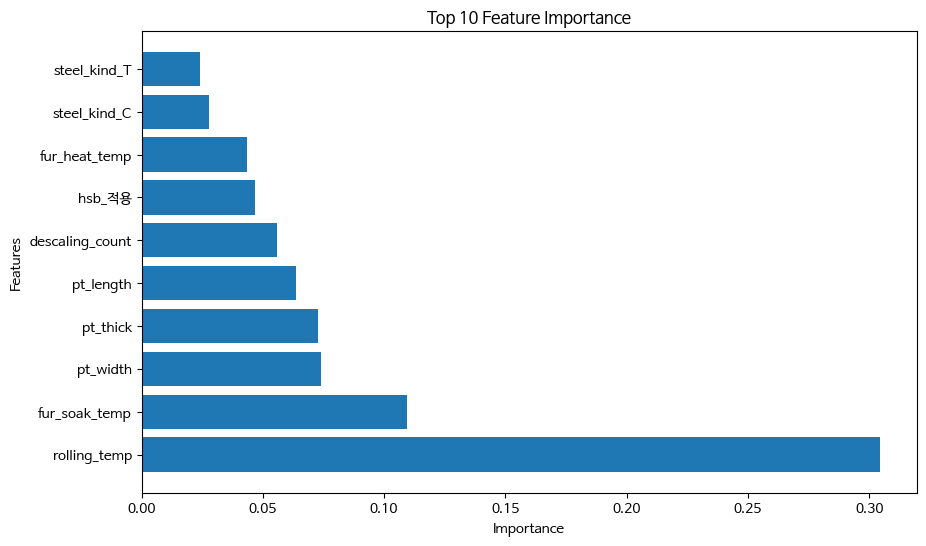

In [ ]:
import matplotlib.pyplot as plt

# 설명변수 중요도를 확인하기 위한 DataFrame 생성
feature_importance = pd.DataFrame()
feature_importance["feature"] = X_train.columns
feature_importance["importance"] = rf_final.feature_importances_

# 중요도에 따라 내림차순으로 정렬
feature_importance_sorted = feature_importance.sort_values(by="importance", ascending=False)

# 상위 10개의 데이터만 선택
top_10_features = feature_importance_sorted.head(10)

# 시각화
plt.figure(figsize=(10, 6))
plt.barh(top_10_features["feature"], top_10_features["importance"])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Top 10 Feature Importance')
plt.show()


 랜덤 포레스트를 사용하여 분류했을 때, 후판 공정에서 불량률을 검출할때 가장 영향을 많이 주는 변수는rolling_temp, fur_soak_Temp, pt_width, pt_length 순으로 중요하다고 추정된다.

In [ ]:
y_pred_train = rf_final.predict(X_train)
y_pred_test = rf_final.predict(X_test)

In [ ]:
train_metrics = pd.concat([train_metrics, metbin(df_train["scale"], y_pred_train, modelname='RandomForest')])
test_metrics = pd.concat([test_metrics, metbin(df_test["scale"], y_pred_test, modelname='RandomForest')])

In [ ]:
test_metrics

,acc,sens,spec,prec,gmean,f1,tn,fp,fn,tp
Logistic,0.824121,0.581818,0.916667,0.727273,0.730297,0.646465,132,12,23,32
scaledLogistic,0.785000,0.500000,0.945312,0.837209,0.687500,0.626087,121,7,36,36
DT,0.974874,0.909091,1.000000,1.000000,0.953463,0.952381,144,0,5,50
RandomForest,0.929648,0.763636,0.993056,0.976744,0.870823,0.857143,143,1,13,42


# Gradinet Boosting

In [ ]:
model = GradientBoostingClassifier()
param_grid = {"learning_rate": [rate / 10 for rate in range(1, 5)],
              "max_depth": [depth for depth in range(3, 11)],
              "min_samples_leaf": [sample_leaf for sample_leaf in range(10, 21)]}

grid_dt = GridSearchCV(model, param_grid, scoring="accuracy", n_jobs = -1)
grid_dt.fit(X_train, y_train)

print("best estimator model: \n{}".format(grid_dt.best_estimator_))
print("\nbest parameter: \n{}".format(grid_dt.best_params_))
print("\nbest score: \n{}".format(grid_dt.best_score_.round(3)))

best estimator model: 
GradientBoostingClassifier(min_samples_leaf=10)

best parameter: 
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 10}

best score: 
0.987


gridsearch를 통해 최적의 파라미터를 찾고 최종 모형에 적용

In [ ]:
gb_final = GradientBoostingClassifier(learning_rate = 0.1, max_depth = 3, min_samples_leaf = 10)
gb_final.fit(X_train, y_train)

GradientBoostingClassifier(min_samples_leaf=10)

In [ ]:
# 설명변수 중요도 확인
feature_importance = pd.DataFrame()
feature_importance["feature"] = X_train.columns
feature_importance["importance"] = gb_final.feature_importances_
feature_importance.sort_values(by="importance", ascending=False)

,feature,importance
8,rolling_temp,0.566555
5,fur_soak_temp,0.153339
86,hsb_적용,0.080636
85,hsb_미적용,0.077977
9,descaling_count,0.067754
...,...,...
38,spec_long_JS-SM400B,0.000000
37,spec_long_JS-SM400A,0.000000
36,spec_long_GL-E36-TM,0.000000
35,spec_long_GL-E32-TM,0.000000


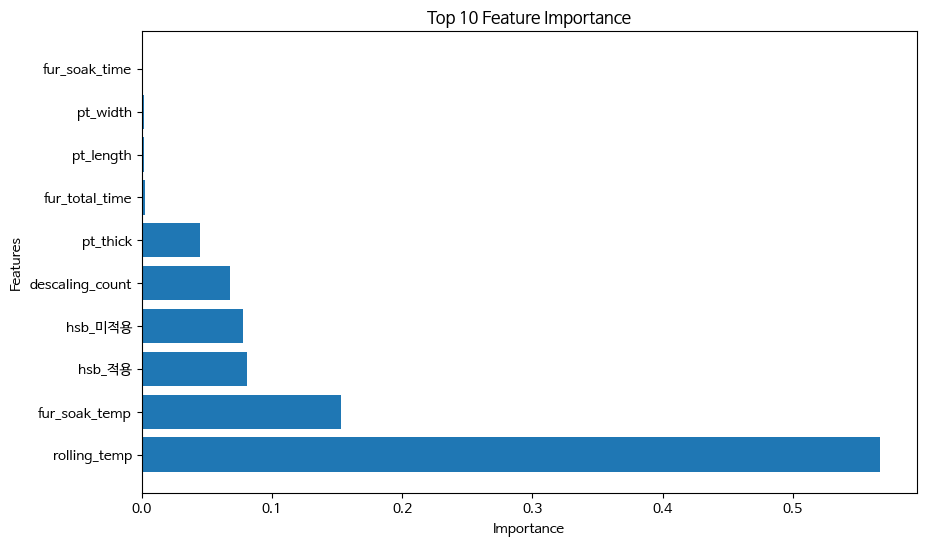

In [ ]:
import matplotlib.pyplot as plt

# 설명변수 중요도를 확인하기 위한 DataFrame 생성
feature_importance = pd.DataFrame()
feature_importance["feature"] = X_train.columns
feature_importance["importance"] = gb_final.feature_importances_

# 중요도에 따라 내림차순으로 정렬
feature_importance_sorted = feature_importance.sort_values(by="importance", ascending=False)

# 상위 10개의 데이터만 선택
top_10_features = feature_importance_sorted.head(10)

# 시각화
plt.figure(figsize=(10, 6))
plt.barh(top_10_features["feature"], top_10_features["importance"])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Top 10 Feature Importance')
plt.show()

그래디언트 부스팅의 불량률 분류에 가장 영향을 많이 주는 변수는 rolling_temp , fur_soak_temp, hsb_적용, hsb_미적용, pt_thick 순으로 중요하다는 것을 추정할 수 있다.

In [ ]:
y_pred_train = gb_final.predict(X_train)
y_pred_test = gb_final.predict(X_test)

In [ ]:
train_metrics = pd.concat([train_metrics, metbin(df_train["scale"], y_pred_train, modelname='GradientBoosting')])
test_metrics = pd.concat([test_metrics, metbin(df_test["scale"], y_pred_test, modelname='GradientBoosting')])

In [ ]:
test_metrics

,acc,sens,spec,prec,gmean,f1,tn,fp,fn,tp
Logistic,0.824121,0.581818,0.916667,0.727273,0.730297,0.646465,132,12,23,32
scaledLogistic,0.785000,0.500000,0.945312,0.837209,0.687500,0.626087,121,7,36,36
DT,0.974874,0.909091,1.000000,1.000000,0.953463,0.952381,144,0,5,50
RandomForest,0.929648,0.763636,0.993056,0.976744,0.870823,0.857143,143,1,13,42
GradientBoosting,0.994975,0.981818,1.000000,1.000000,0.990867,0.990826,144,0,1,54


# K-NN

In [ ]:
df_raw

,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,fur_no,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group,rotation
0,0,AB/EH32-TM,미국,T,32,3700,15100,적용,1호기,1열,1144,116,1133,59,259,TMCP(온도제어),934,8,1조,주간
1,0,AB/EH32-TM,미국,T,32,3700,15100,적용,1호기,2열,1144,122,1135,53,238,TMCP(온도제어),937,8,1조,주간
2,0,NV-E36-TM,영국,T,33,3600,19200,적용,2호기,1열,1129,116,1121,55,258,TMCP(온도제어),889,8,1조,주간
3,0,NV-E36-TM,영국,T,33,3600,19200,적용,2호기,2열,1152,125,1127,68,266,TMCP(온도제어),885,8,1조,주간
4,0,BV-EH36-TM,프랑스,T,38,3100,13300,적용,3호기,1열,1140,134,1128,48,246,TMCP(온도제어),873,8,1조,주간
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,BV-A,프랑스,C,19,3400,41500,적용,1호기,2열,1142,55,1151,86,203,CR(제어압연),948,10,4조,야간
996,0,LR-A,영국,C,19,3400,41500,적용,1호기,2열,1142,55,1151,86,209,CR(제어압연),948,10,4조,야간
997,0,AB/AH32,미국,C,17,3400,43700,적용,2호기,2열,1169,65,1163,77,227,CR(제어압연),948,10,4조,야간
998,0,NV-A32,영국,C,17,3400,43700,적용,2호기,2열,1169,65,1163,77,204,CR(제어압연),948,10,4조,야간


In [ ]:
df_raw.isnull().sum()

scale              0
spec_long          0
spec_country       0
steel_kind         0
pt_thick           0
pt_width           0
pt_length          0
hsb                0
fur_no             0
fur_input_row      0
fur_heat_temp      0
fur_heat_time      0
fur_soak_temp      0
fur_soak_time      0
fur_total_time     0
rolling_method     0
rolling_temp       0
descaling_count    0
work_group         0
rotation           0
dtype: int64

In [ ]:
df_raw.dtypes

scale               int64
spec_long          object
spec_country       object
steel_kind         object
pt_thick            int64
pt_width            int64
pt_length           int64
hsb                object
fur_no             object
fur_input_row      object
fur_heat_temp       int64
fur_heat_time       int64
fur_soak_temp       int64
fur_soak_time       int64
fur_total_time      int64
rolling_method     object
rolling_temp        int64
descaling_count     int64
work_group         object
rotation           object
dtype: object

In [ ]:
#문자형, 숫자형 변수 골라서 스케일링, 더미화 변환하기
df_char = df_raw.select_dtypes(include = "object")
df_numeric = df_raw.select_dtypes(exclude = "object")


# Data Scaling
scaler = StandardScaler()
np_numeric_scaled = scaler.fit_transform(df_numeric)
df_numeric_scaled = pd.DataFrame(np_numeric_scaled, columns = df_numeric.columns)

df_numeric_scaled

,scale,pt_thick,pt_width,pt_length,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_temp,descaling_count
0,-0.673213,0.297380,1.758916,-1.568542,-0.629006,1.138138,-1.042290,-0.617512,0.531891,-0.098376,-0.353037
1,-0.673213,0.297380,1.758916,-1.568542,-0.629006,1.365628,-0.926564,-0.908186,-0.017312,-0.051371,-0.353037
2,-0.673213,0.352984,1.555807,-1.273013,-1.336122,1.138138,-1.736646,-0.811295,0.505738,-0.803452,-0.353037
3,-0.673213,0.352984,1.555807,-1.273013,-0.251878,1.479374,-1.389468,-0.181501,0.714959,-0.866125,-0.353037
4,-0.673213,0.631008,0.540262,-1.698287,-0.817571,1.820609,-1.331605,-1.150415,0.191908,-1.054145,-0.353037
...,...,...,...,...,...,...,...,...,...,...,...
989,-0.673213,-0.425483,1.149589,0.334375,-0.723288,-1.174680,-0.000757,0.690522,-0.932651,0.120980,0.898011
990,-0.673213,-0.425483,1.149589,0.334375,-0.723288,-1.174680,-0.000757,0.690522,-0.775736,0.120980,0.898011
991,-0.673213,-0.536693,1.149589,0.492952,0.549521,-0.795529,0.693599,0.254510,-0.304990,0.120980,0.898011
992,-0.673213,-0.536693,1.149589,0.492952,0.549521,-0.795529,0.693599,0.254510,-0.906498,0.120980,0.898011


In [ ]:
df_numeric_scaled.isnull().sum()

scale              0
pt_thick           0
pt_width           0
pt_length          0
fur_heat_temp      0
fur_heat_time      0
fur_soak_temp      0
fur_soak_time      0
fur_total_time     0
rolling_temp       0
descaling_count    0
dtype: int64

In [ ]:
df_dummy = pd.get_dummies(df_char)


df_dummy


,spec_long_A131-DH36TM,spec_long_A283-C,spec_long_A516-60,spec_long_A709-36,spec_long_AB/A,spec_long_AB/AH32,spec_long_AB/B,spec_long_AB/EH32-TM,spec_long_AB/EH36-TM,spec_long_API-2W-50T,...,fur_input_row_1열,fur_input_row_2열,rolling_method_CR(제어압연),rolling_method_TMCP(온도제어),work_group_1조,work_group_2조,work_group_3조,work_group_4조,rotation_야간,rotation_주간
0,0,0,0,0,0,0,0,1,0,0,...,1,0,0,1,1,0,0,0,0,1
1,0,0,0,0,0,0,0,1,0,0,...,0,1,0,1,1,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,1,0,0,1,1,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,1,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,1,0,0,1,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,1,1,0
996,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,1,1,0
997,0,0,0,0,0,1,0,0,0,0,...,0,1,1,0,0,0,0,1,1,0
998,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,1,1,0


In [ ]:
df_dummy.isnull().sum()

spec_long_A131-DH36TM    0
spec_long_A283-C         0
spec_long_A516-60        0
spec_long_A709-36        0
spec_long_AB/A           0
                        ..
work_group_2조            0
work_group_3조            0
work_group_4조            0
rotation_야간              0
rotation_주간              0
Length: 90, dtype: int64

In [ ]:
# df_numeric_scaled와 df_dummy의 인덱스를 일치시키기
df_numeric_scaled.reset_index(drop=True, inplace=True)  # 기존 인덱스 제거하고 새로운 인덱스 생성
df_dummy.reset_index(drop=True, inplace=True)  # 기존 인덱스 제거하고 새로운 인덱스 생성

# 데이터프레임 합치기
df_scaled = pd.concat([df_numeric_scaled, df_dummy], axis=1)


In [ ]:
df_scaled.isnull().sum()

scale            0
pt_thick         0
pt_width         0
pt_length        0
fur_heat_temp    0
                ..
work_group_2조    0
work_group_3조    0
work_group_4조    0
rotation_야간      0
rotation_주간      0
Length: 101, dtype: int64

스케일링 된 목표변수 다시 0,1 값으로 바꾸기

In [ ]:
df_scaled["scale"] = np.where(df_scaled["scale"]> 0, 1, 0)
df_scaled.head()

,scale,pt_thick,pt_width,pt_length,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_temp,...,fur_input_row_1열,fur_input_row_2열,rolling_method_CR(제어압연),rolling_method_TMCP(온도제어),work_group_1조,work_group_2조,work_group_3조,work_group_4조,rotation_야간,rotation_주간
0,0,0.297380,1.758916,-1.568542,-0.629006,1.138138,-1.042290,-0.617512,0.531891,-0.098376,...,1,0,0,1,1,0,0,0,0,1
1,0,0.297380,1.758916,-1.568542,-0.629006,1.365628,-0.926564,-0.908186,-0.017312,-0.051371,...,0,1,0,1,1,0,0,0,0,1
2,0,0.352984,1.555807,-1.273013,-1.336122,1.138138,-1.736646,-0.811295,0.505738,-0.803452,...,1,0,0,1,1,0,0,0,0,1
3,0,0.352984,1.555807,-1.273013,-0.251878,1.479374,-1.389468,-0.181501,0.714959,-0.866125,...,0,1,0,1,1,0,0,0,0,1
4,0,0.631008,0.540262,-1.698287,-0.817571,1.820609,-1.331605,-1.150415,0.191908,-1.054145,...,1,0,0,1,1,0,0,0,0,1


In [ ]:
#데이터 분할

scaled_x = df_scaled.drop("scale", axis = 1, inplace = False)
scaled_y = df_scaled["scale"]


X_train, X_test, y_train, y_test = train_test_split(scaled_x, scaled_y, test_size = 0.2, random_state = 1234)

In [ ]:
# 군집 방법 : AgglomerativeClustering(계층형), KMeans(k-평균), DBSCAN
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN

# 실루엣(Silhouette) 계수 산출
from sklearn.metrics import silhouette_samples, silhouette_score
# 실루엣 계수 산출 및 시각화 라이브러리 (pip install yellowbrick 실행)
from yellowbrick.cluster import SilhouetteVisualizer

In [ ]:
# 최대 군집 개수 설정하기
n_iter_neighbor = 50
neighbor_range = [i+1 for i in range(n_iter_neighbor)]
train_accuracy = []; test_accuracy = []
for n_neighbor in neighbor_range:
    knn = KNeighborsClassifier(n_neighbors = n_neighbor)
    knn.fit(X_train, y_train)
    # 각 데이터와 가장 가까운 군집 중심접까지의 거리 제곱합 계산후 train_accuracy,test_accuarcy에 저장
    train_accuracy.append(knn.score(X_train, y_train))
    test_accuracy.append(knn.score(X_test, y_test))

In [ ]:
knn_accuracy = pd.DataFrame({"NumberOfNeighbors": neighbor_range, "TrainAccuracy": train_accuracy, "TestAccuracy": test_accuracy})
knn_accuracy.round(3)

,NumberOfNeighbors,TrainAccuracy,TestAccuracy
0,1,1.000,0.804
1,2,0.889,0.799
2,3,0.899,0.834
3,4,0.869,0.839
4,5,0.883,0.834
5,6,0.860,0.829
6,7,0.865,0.839
7,8,0.843,0.834
8,9,0.843,0.844
9,10,0.843,0.834


<Axes: xlabel='NumberOfNeighbors', ylabel='value'>

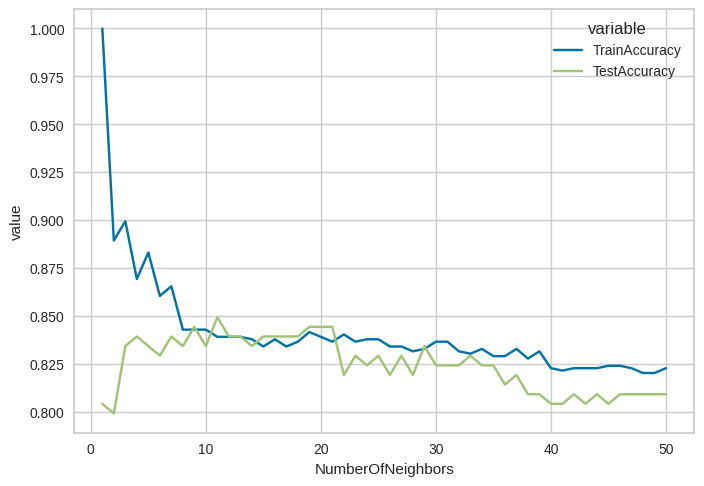

In [ ]:
knn_accuracy_melt = pd.melt(knn_accuracy, id_vars = "NumberOfNeighbors")
sns.lineplot(x = "NumberOfNeighbors", y = "value", hue = "variable", data = knn_accuracy_melt)

그래프 결과와 train/test 데이터 성능변화를 고려하여 k는 5개로 결정

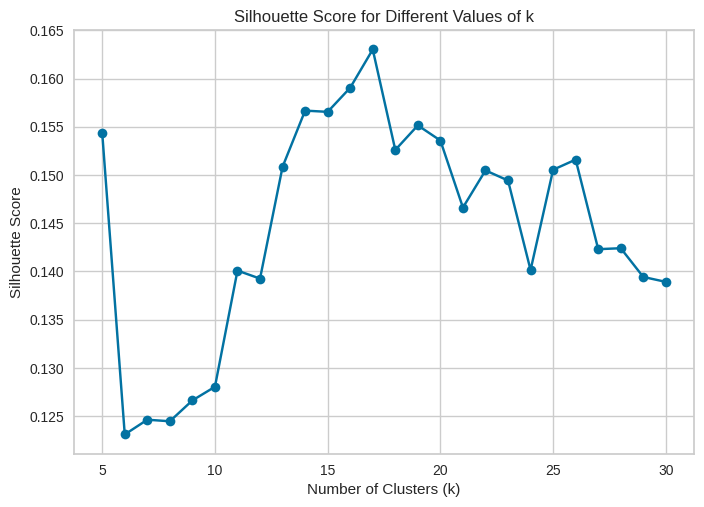

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터셋을 이용하여 k값에 따른 실루엣 계수를 계산하는 함수
def calculate_silhouette_score(X_train, k):
    kmeans = KMeans(n_clusters=k)
    cluster_labels = kmeans.fit_predict(X_train)
    silhouette_avg = silhouette_score(X_train, cluster_labels)
    return silhouette_avg

# k값의 범위 설정
k_range = range(5, 31)

# 각 k값에 대한 실루엣 계수 계산
silhouette_scores = [calculate_silhouette_score(X_train, k) for k in k_range]

# 실루엣 계수를 시각화하여 엘보우 포인트 찾기
plt.plot(k_range, silhouette_scores, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different Values of k')
plt.show()


In [ ]:
calculate_silhouette_score(X_train, 5)

0.15386546094556677

train - 0.883
test - 0.834
실루엣 계수 : 0.153

K = 5개로 결정

In [ ]:
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)

모델 분류 성능 비교 지표

In [ ]:
train_metrics = pd.concat([train_metrics, metbin(y_train, y_pred_train, modelname='KNN')])
test_metrics = pd.concat([test_metrics, metbin(y_test, y_pred_test, modelname='KNN')])

In [ ]:
test_metrics

,acc,sens,spec,prec,gmean,f1,tn,fp,fn,tp
Logistic,0.824121,0.581818,0.916667,0.727273,0.730297,0.646465,132,12,23,32
scaledLogistic,0.785000,0.500000,0.945312,0.837209,0.687500,0.626087,121,7,36,36
DT,0.974874,0.909091,1.000000,1.000000,0.953463,0.952381,144,0,5,50
RandomForest,0.929648,0.763636,0.993056,0.976744,0.870823,0.857143,143,1,13,42
GradientBoosting,0.994975,0.981818,1.000000,1.000000,0.990867,0.990826,144,0,1,54
KNN,0.834171,0.581818,0.930556,0.761905,0.735808,0.659794,134,10,23,32


In [ ]:
train_metrics

,acc,sens,spec,prec,gmean,f1,tn,fp,fn,tp
Logistic,0.828931,0.678431,0.900000,0.762115,0.781401,0.717842,486,54,82,173
scaledLogistic,0.840000,0.638655,0.925267,0.783505,0.768718,0.703704,520,42,86,152
DT,0.963522,0.886275,1.000000,1.000000,0.941422,0.939709,540,0,29,226
RandomForest,0.935849,0.800000,1.000000,1.000000,0.894427,0.888889,540,0,51,204
GradientBoosting,0.993711,0.980392,1.000000,1.000000,0.990148,0.990099,540,0,5,250
KNN,0.883019,0.729412,0.955556,0.885714,0.834861,0.800000,516,24,69,186


# SVM

In [ ]:
df_raw

,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,fur_no,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group,rotation
0,0,AB/EH32-TM,미국,T,32,3700,15100,적용,1호기,1열,1144,116,1133,59,259,TMCP(온도제어),934,8,1조,주간
1,0,AB/EH32-TM,미국,T,32,3700,15100,적용,1호기,2열,1144,122,1135,53,238,TMCP(온도제어),937,8,1조,주간
2,0,NV-E36-TM,영국,T,33,3600,19200,적용,2호기,1열,1129,116,1121,55,258,TMCP(온도제어),889,8,1조,주간
3,0,NV-E36-TM,영국,T,33,3600,19200,적용,2호기,2열,1152,125,1127,68,266,TMCP(온도제어),885,8,1조,주간
4,0,BV-EH36-TM,프랑스,T,38,3100,13300,적용,3호기,1열,1140,134,1128,48,246,TMCP(온도제어),873,8,1조,주간
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,BV-A,프랑스,C,19,3400,41500,적용,1호기,2열,1142,55,1151,86,203,CR(제어압연),948,10,4조,야간
996,0,LR-A,영국,C,19,3400,41500,적용,1호기,2열,1142,55,1151,86,209,CR(제어압연),948,10,4조,야간
997,0,AB/AH32,미국,C,17,3400,43700,적용,2호기,2열,1169,65,1163,77,227,CR(제어압연),948,10,4조,야간
998,0,NV-A32,영국,C,17,3400,43700,적용,2호기,2열,1169,65,1163,77,204,CR(제어압연),948,10,4조,야간


In [ ]:
#문자형, 숫자형 변수 골라서 스케일링, 더미화 변환하기
df_char = df_raw.select_dtypes(include = "object")
df_numeric = df_raw.select_dtypes(exclude = "object")


# Data Scaling
scaler = StandardScaler()
np_numeric_scaled = scaler.fit_transform(df_numeric)
df_numeric_scaled = pd.DataFrame(np_numeric_scaled, columns = df_numeric.columns)

df_dummy = pd.get_dummies(df_char)

# df_numeric_scaled와 df_dummy의 인덱스를 일치시키기
df_numeric_scaled.reset_index(drop=True, inplace=True)  # 기존 인덱스 제거하고 새로운 인덱스 생성
df_dummy.reset_index(drop=True, inplace=True)  # 기존 인덱스 제거하고 새로운 인덱스 생성

# 데이터프레임 합치기
df_scaled = pd.concat([df_numeric_scaled, df_dummy], axis=1)

In [ ]:
df_scaled["scale"] = np.where(df_scaled["scale"]> 0, 1, 0)
df_scaled.head()

,scale,pt_thick,pt_width,pt_length,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_temp,...,fur_input_row_1열,fur_input_row_2열,rolling_method_CR(제어압연),rolling_method_TMCP(온도제어),work_group_1조,work_group_2조,work_group_3조,work_group_4조,rotation_야간,rotation_주간
0,0,0.297380,1.758916,-1.568542,-0.629006,1.138138,-1.042290,-0.617512,0.531891,-0.098376,...,1,0,0,1,1,0,0,0,0,1
1,0,0.297380,1.758916,-1.568542,-0.629006,1.365628,-0.926564,-0.908186,-0.017312,-0.051371,...,0,1,0,1,1,0,0,0,0,1
2,0,0.352984,1.555807,-1.273013,-1.336122,1.138138,-1.736646,-0.811295,0.505738,-0.803452,...,1,0,0,1,1,0,0,0,0,1
3,0,0.352984,1.555807,-1.273013,-0.251878,1.479374,-1.389468,-0.181501,0.714959,-0.866125,...,0,1,0,1,1,0,0,0,0,1
4,0,0.631008,0.540262,-1.698287,-0.817571,1.820609,-1.331605,-1.150415,0.191908,-1.054145,...,1,0,0,1,1,0,0,0,0,1


In [ ]:
#데이터 분할

scaled_x = df_scaled.drop("scale", axis = 1, inplace = False)
scaled_y = df_scaled["scale"]


X_train, X_test, y_train, y_test = train_test_split(scaled_x, scaled_y, test_size = 0.2, random_state = 1234)

In [ ]:
# 데이터 scaling
from sklearn.preprocessing import StandardScaler
# 데이터 분할:train, test
from sklearn.model_selection import train_test_split
# 분류 SVM
from sklearn.svm import SVC
# 최적 모델, 파라미터 탐색
from sklearn.model_selection import GridSearchCV

In [ ]:
estimator = SVC(random_state=1234)
# 구하고자 하는 parameter와 범위


param_grid = {"C": [10 **c for c in range(-2, 3)],
              "gamma": [0.1 * gamma for gamma in range(1, 11)] }
# 정확도가 높은 최적 parameter 찾기
grid_svm= GridSearchCV(estimator, param_grid, scoring="accuracy", n_jobs = -1)
grid_svm.fit(X_train, y_train)
print("best estimator model: \n{}".format(grid_svm.best_estimator_))
print("\nbest parameter: \n{}".format(grid_svm.best_params_))
print("\nbest score: \n{}".format(grid_svm.best_score_.round(3)))

best estimator model: 
SVC(C=1, gamma=0.1, random_state=1234)

best parameter: 
{'C': 1, 'gamma': 0.1}

best score: 
0.879


In [ ]:
# 최종 모델
svc_final = SVC(gamma=0.1, C=1, random_state=1234)
svc_final.fit(X_train, y_train)

# 평가
y_pred = svc_final.predict(X_test)

# train 모델 정확도
print("Train Accucary : {:.3f}".format(svc_final.score(X_train, y_train)))
# test 모델 정확도
print("Test Accuracy : {:.3f}\n".format(svc_final.score(X_test, y_test)))
# confusion matrix
print("Test Confusion matrix: \n{}".format(confusion_matrix(y_test, y_pred)))

# 목표변수의 빈도 불균형 : f1 score로 모델 평가
print(classification_report(y_test, y_pred, digits=3))

Train Accucary : 0.931
Test Accuracy : 0.889

Test Confusion matrix: 
[[137   7]
 [ 15  40]]
              precision    recall  f1-score   support

           0      0.901     0.951     0.926       144
           1      0.851     0.727     0.784        55

    accuracy                          0.889       199
   macro avg      0.876     0.839     0.855       199
weighted avg      0.887     0.889     0.887       199



In [ ]:
y_pred_train = svc_final.predict(X_train)
y_pred_test = svc_final.predict(X_test)

In [ ]:
train_metrics = pd.concat([train_metrics, metbin(y_train, y_pred_train, modelname='SVM')])
test_metrics = pd.concat([test_metrics, metbin(y_test, y_pred_test, modelname='SVM')])

In [ ]:
test_metrics

,acc,sens,spec,prec,gmean,f1,tn,fp,fn,tp
Logistic,0.824121,0.581818,0.916667,0.727273,0.730297,0.646465,132,12,23,32
scaledLogistic,0.785000,0.500000,0.945312,0.837209,0.687500,0.626087,121,7,36,36
DT,0.974874,0.909091,1.000000,1.000000,0.953463,0.952381,144,0,5,50
RandomForest,0.929648,0.763636,0.993056,0.976744,0.870823,0.857143,143,1,13,42
GradientBoosting,0.994975,0.981818,1.000000,1.000000,0.990867,0.990826,144,0,1,54
KNN,0.834171,0.581818,0.930556,0.761905,0.735808,0.659794,134,10,23,32
SVM,0.889447,0.727273,0.951389,0.851064,0.831817,0.784314,137,7,15,40


In [ ]:
test_T = test_metrics.T
test_T

,Logistic,scaledLogistic,DT,RandomForest,GradientBoosting,KNN,SVM
acc,0.824121,0.785000,0.974874,0.929648,0.994975,0.834171,0.889447
sens,0.581818,0.500000,0.909091,0.763636,0.981818,0.581818,0.727273
spec,0.916667,0.945312,1.000000,0.993056,1.000000,0.930556,0.951389
prec,0.727273,0.837209,1.000000,0.976744,1.000000,0.761905,0.851064
gmean,0.730297,0.687500,0.953463,0.870823,0.990867,0.735808,0.831817
f1,0.646465,0.626087,0.952381,0.857143,0.990826,0.659794,0.784314
tn,132.000000,121.000000,144.000000,143.000000,144.000000,134.000000,137.000000
fp,12.000000,7.000000,0.000000,1.000000,0.000000,10.000000,7.000000
fn,23.000000,36.000000,5.000000,13.000000,1.000000,23.000000,15.000000
tp,32.000000,36.000000,50.000000,42.000000,54.000000,32.000000,40.000000


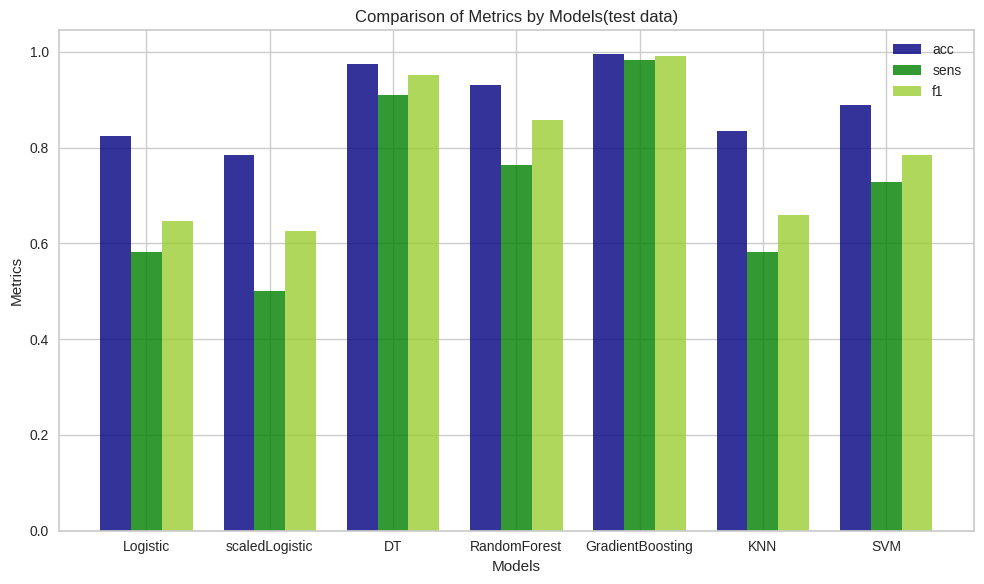

In [ ]:
models = list(test_T.keys())
metrics = ['acc', 'sens', 'f1']

# 그래프 그리기
x = np.arange(len(models))  # x 축 범위 설정
bar_width = 0.25  # 막대의 너비
opacity = 0.8  # 투명도
colors = ['navy', 'green', 'yellowgreen']  # 각 데이터의 색깔 설정

plt.figure(figsize=(10, 6))

# 각 모델별로 막대 그래프 그리기
for i, metric in enumerate(metrics):
    plt.bar(x + i * bar_width, [test_T[model][metric] for model in models], bar_width, alpha=opacity, label=metric, color=colors[i])

plt.xlabel('Models')
plt.ylabel('Metrics')
plt.title('Comparison of Metrics by Models(test data)')
plt.xticks(x + bar_width, models)  # x 축 눈금 라벨 설정
plt.legend()  # 범례 추가

plt.tight_layout()
plt.show()

In [ ]:
train_metrics

,acc,sens,spec,prec,gmean,f1,tn,fp,fn,tp
Logistic,0.828931,0.678431,0.900000,0.762115,0.781401,0.717842,486,54,82,173
scaledLogistic,0.840000,0.638655,0.925267,0.783505,0.768718,0.703704,520,42,86,152
DT,0.963522,0.886275,1.000000,1.000000,0.941422,0.939709,540,0,29,226
RandomForest,0.935849,0.800000,1.000000,1.000000,0.894427,0.888889,540,0,51,204
GradientBoosting,0.993711,0.980392,1.000000,1.000000,0.990148,0.990099,540,0,5,250
KNN,0.883019,0.729412,0.955556,0.885714,0.834861,0.800000,516,24,69,186
SVM,0.930818,0.819608,0.983333,0.958716,0.897746,0.883721,531,9,46,209


In [ ]:
train_T = train_metrics.T
train_T

,Logistic,scaledLogistic,DT,RandomForest,GradientBoosting,KNN,SVM
acc,0.828931,0.840000,0.963522,0.935849,0.993711,0.883019,0.930818
sens,0.678431,0.638655,0.886275,0.800000,0.980392,0.729412,0.819608
spec,0.900000,0.925267,1.000000,1.000000,1.000000,0.955556,0.983333
prec,0.762115,0.783505,1.000000,1.000000,1.000000,0.885714,0.958716
gmean,0.781401,0.768718,0.941422,0.894427,0.990148,0.834861,0.897746
f1,0.717842,0.703704,0.939709,0.888889,0.990099,0.800000,0.883721
tn,486.000000,520.000000,540.000000,540.000000,540.000000,516.000000,531.000000
fp,54.000000,42.000000,0.000000,0.000000,0.000000,24.000000,9.000000
fn,82.000000,86.000000,29.000000,51.000000,5.000000,69.000000,46.000000
tp,173.000000,152.000000,226.000000,204.000000,250.000000,186.000000,209.000000


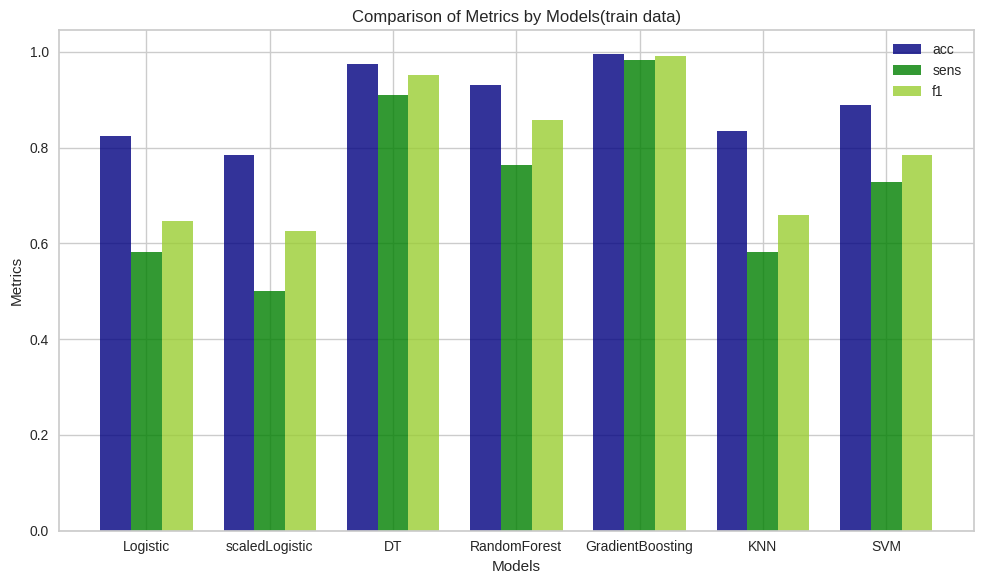

In [ ]:
models = list(train_T.keys())
metrics = ['acc', 'sens', 'f1']

# 그래프 그리기
x = np.arange(len(models))  # x 축 범위 설정
bar_width = 0.25  # 막대의 너비
opacity = 0.8  # 투명도
colors = ['navy', 'green', 'yellowgreen']  # 각 데이터의 색깔 설정

plt.figure(figsize=(10, 6))

# 각 모델별로 막대 그래프 그리기
for i, metric in enumerate(metrics):
    plt.bar(x + i * bar_width, [test_T[model][metric] for model in models], bar_width, alpha=opacity, label=metric, color=colors[i])

plt.xlabel('Models')
plt.ylabel('Metrics')
plt.title('Comparison of Metrics by Models(train data)')
plt.xticks(x + bar_width, models)  # x 축 눈금 라벨 설정
plt.legend()  # 범례 추가

plt.tight_layout()
plt.show()

# 최종 모델 : Gradient Boosting !!!!